In [1]:

import numpy as np



In [2]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [6]:
df=pd.read_csv('StudentPerformanceFactors.csv')

In [7]:
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [8]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [9]:
df.tail()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


In [10]:
df.shape

(6607, 20)

In [11]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [12]:
df.dtypes

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

In [13]:
df.isnull.sum()

AttributeError: 'function' object has no attribute 'sum'

In [14]:
df.isnull().sum

<bound method DataFrame.sum of       Hours_Studied  Attendance  Parental_Involvement  Access_to_Resources  \
0             False       False                 False                False   
1             False       False                 False                False   
2             False       False                 False                False   
3             False       False                 False                False   
4             False       False                 False                False   
...             ...         ...                   ...                  ...   
6602          False       False                 False                False   
6603          False       False                 False                False   
6604          False       False                 False                False   
6605          False       False                 False                False   
6606          False       False                 False                False   

      Extracurricular_Activities

In [15]:
df.isnull()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6603,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6604,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6605,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [16]:
df.isnull.sum()

AttributeError: 'function' object has no attribute 'sum'

In [17]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [18]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
6602    False
6603    False
6604    False
6605    False
6606    False
Length: 6607, dtype: bool

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.describe

<bound method NDFrame.describe of       Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0                23          84                  Low                High   
1                19          64                  Low              Medium   
2                24          98               Medium              Medium   
3                29          89                  Low              Medium   
4                19          92               Medium              Medium   
...             ...         ...                  ...                 ...   
6602             25          69                 High              Medium   
6603             23          76                 High              Medium   
6604             20          90               Medium                 Low   
6605             10          86                 High                High   
6606             15          67               Medium                 Low   

     Extracurricular_Activities  Sleep_Hours  Previou

In [21]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [22]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

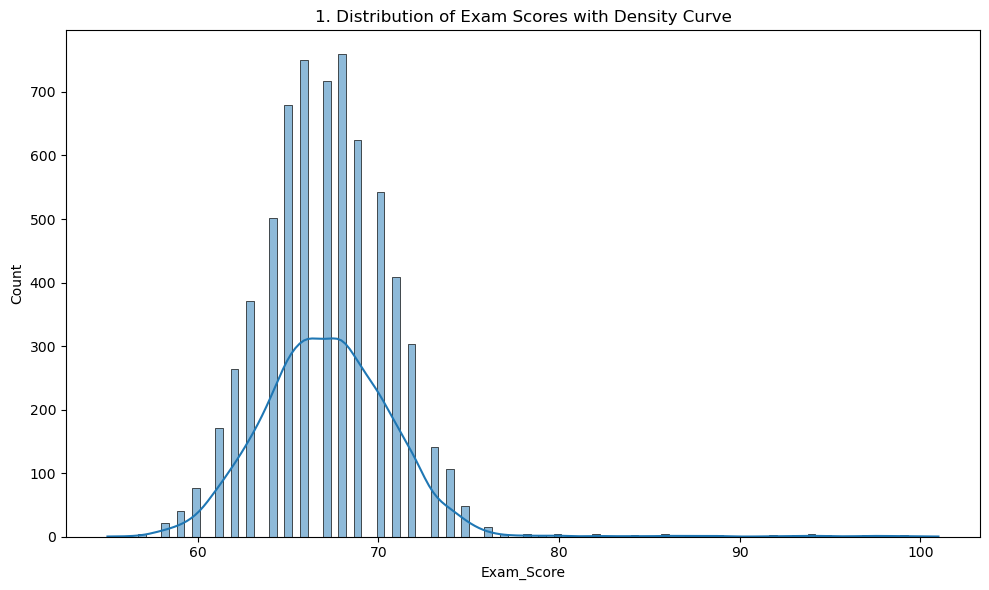

In [23]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Exam_Score'], kde=True)
plt.title(f'{plot_no}. Distribution of Exam Scores with Density Curve')
show_fig()
plot_no += 1

In [24]:
df1=pd.read_csv('Modified_StudentPerformance.csv')

In [25]:
df1

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Modified_Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,100.0
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,96.0
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,100.0
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,100.0
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,70,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,...,Medium,Public,Positive,2,No,High School,Near,Female,68,100.0
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,...,High,Public,Positive,2,No,High School,Near,Female,69,100.0
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68,100.0
6605,10,86,High,High,Yes,6,91,High,Yes,2,...,Medium,Private,Positive,3,No,High School,Far,Female,68,100.0


In [26]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [27]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

In [28]:
df=pd.read_csv('Modified_StudentPerformance.csv')

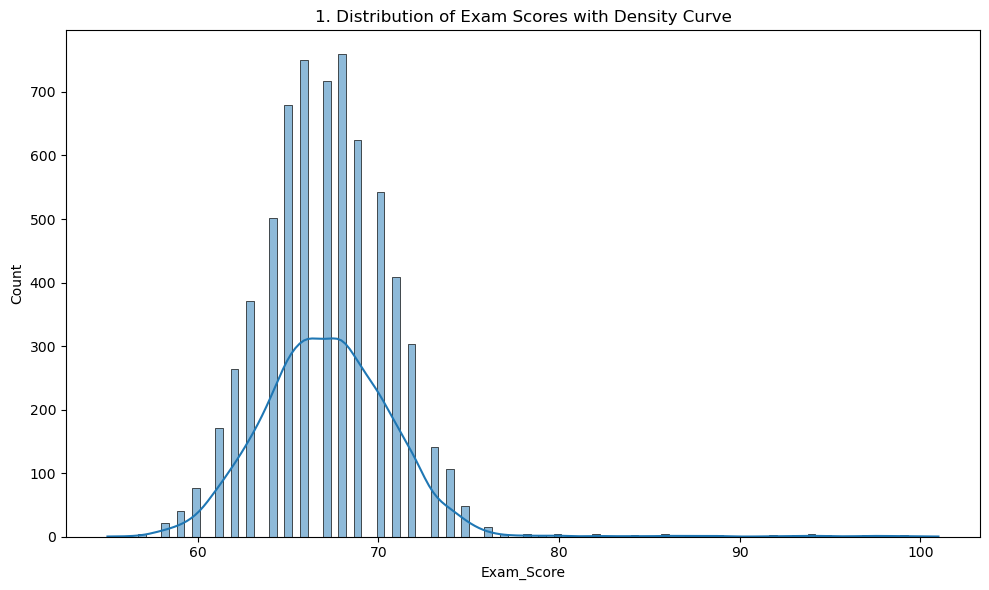

In [29]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Exam_Score'], kde=True)
plt.title(f'{plot_no}. Distribution of Exam Scores with Density Curve')
show_fig()
plot_no += 1

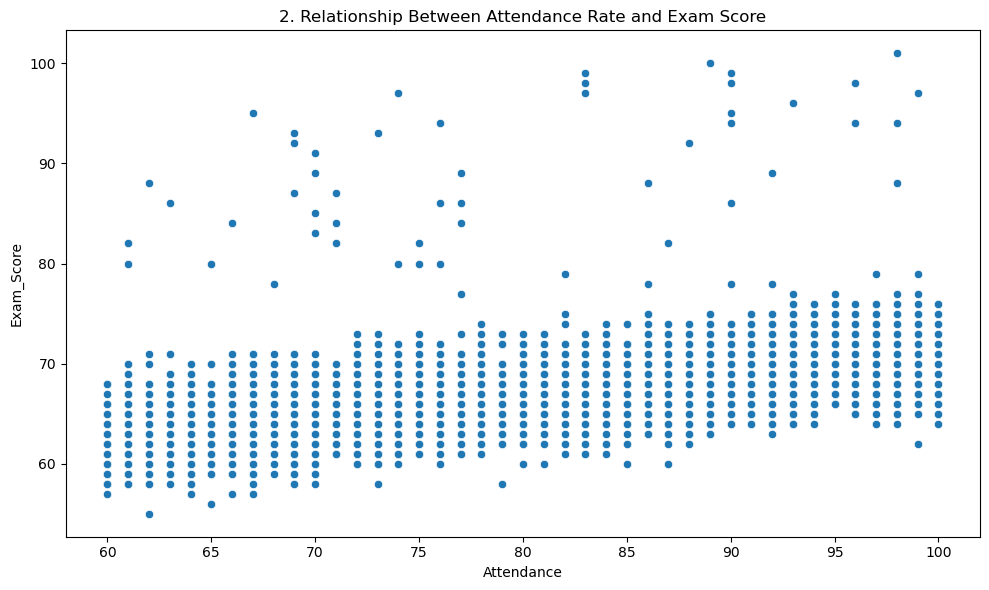

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Attendance', y='Exam_Score')
plt.title(f'{plot_no}. Relationship Between Attendance Rate and Exam Score')
show_fig()
plot_no += 1

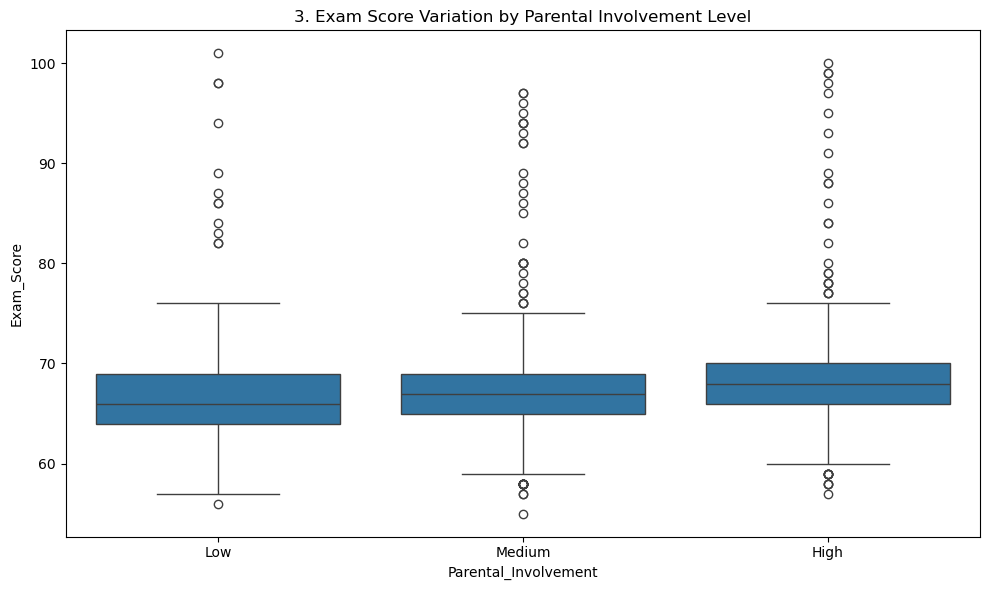

In [31]:

fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Parental_Involvement', y='Exam_Score')
plt.title(f'{plot_no}. Exam Score Variation by Parental Involvement Level')
show_fig()
plot_no += 1

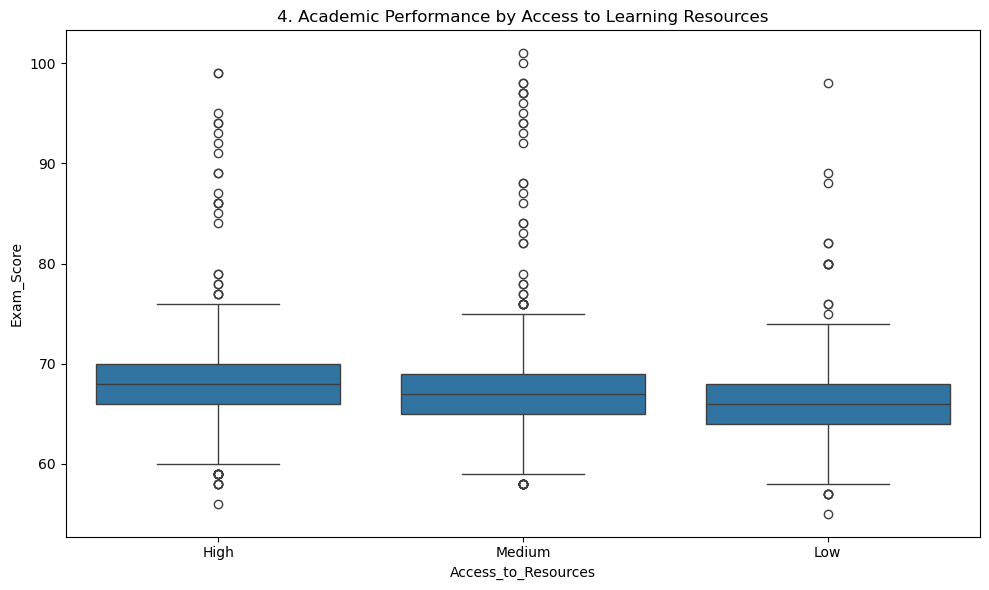

In [32]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Access_to_Resources', y='Exam_Score')
plt.title(f'{plot_no}. Academic Performance by Access to Learning Resources')
show_fig()
plot_no += 1

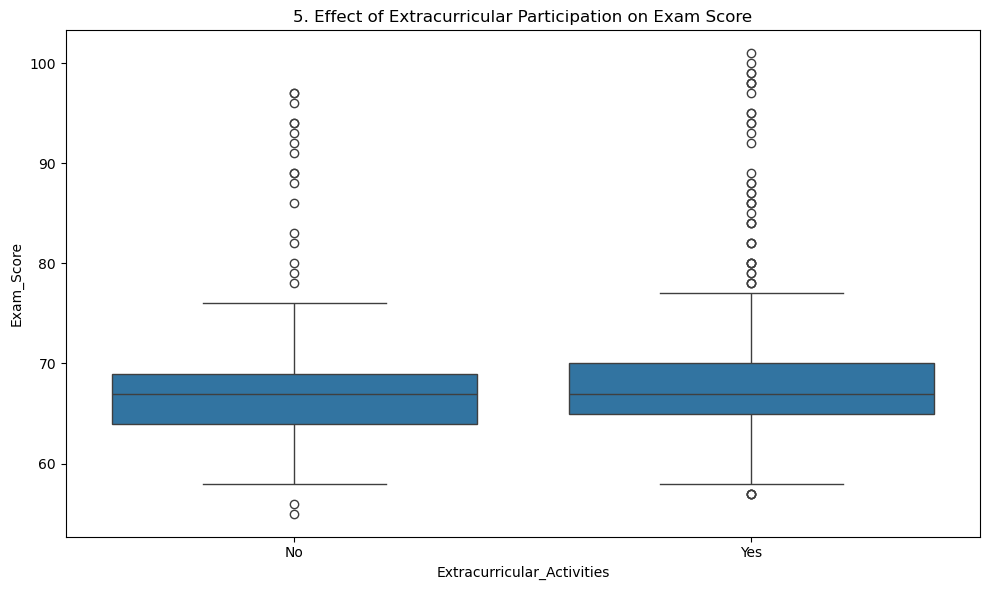

In [33]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Extracurricular_Activities', y='Exam_Score')
plt.title(f'{plot_no}. Effect of Extracurricular Participation on Exam Score')
show_fig()
plot_no += 1

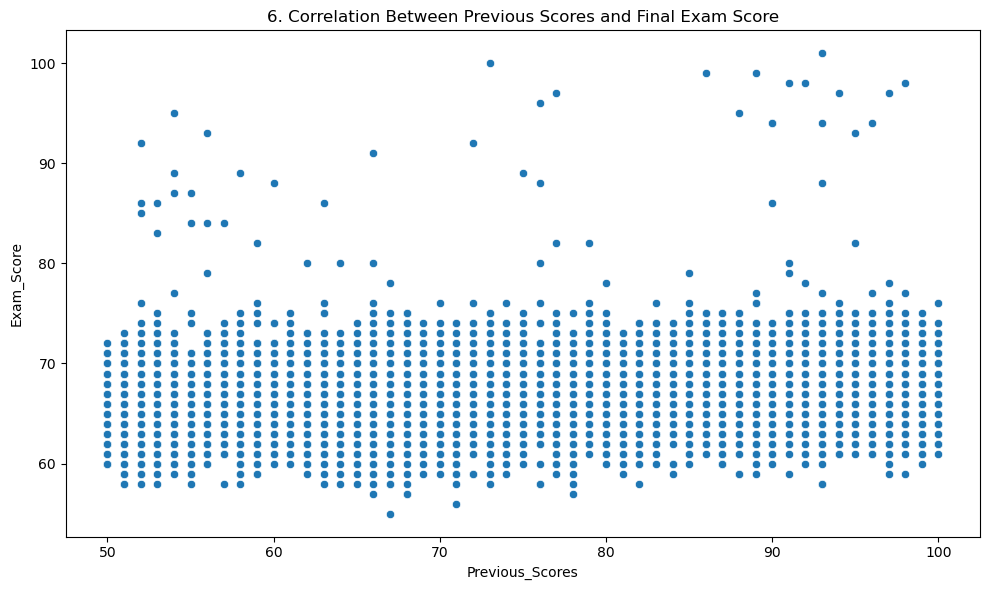

In [34]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Previous_Scores', y='Exam_Score')
plt.title(f'{plot_no}. Correlation Between Previous Scores and Final Exam Score')
show_fig()
plot_no += 1

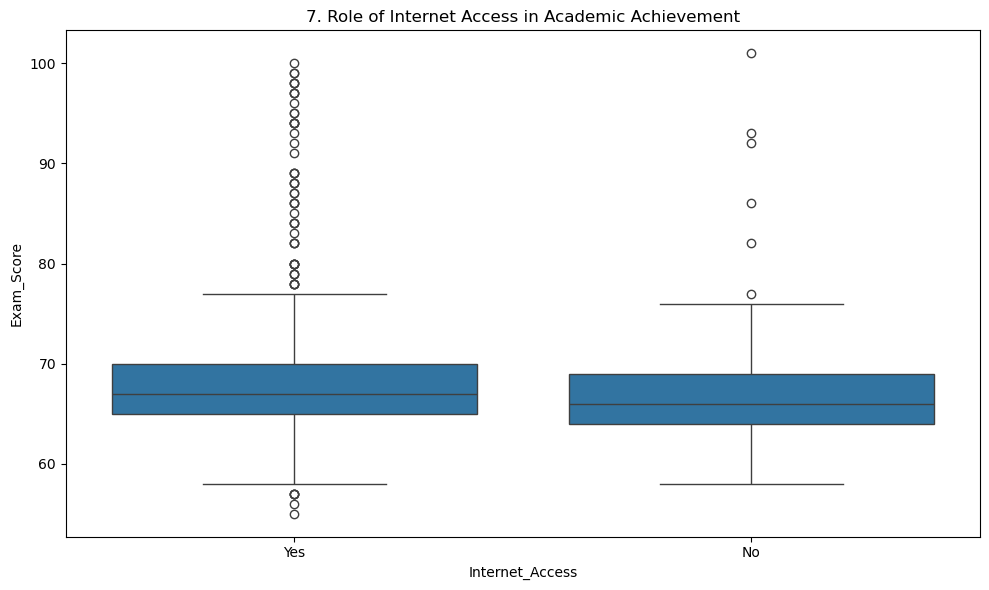

In [35]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Internet_Access', y='Exam_Score')
plt.title(f'{plot_no}. Role of Internet Access in Academic Achievement')
show_fig()
plot_no += 1

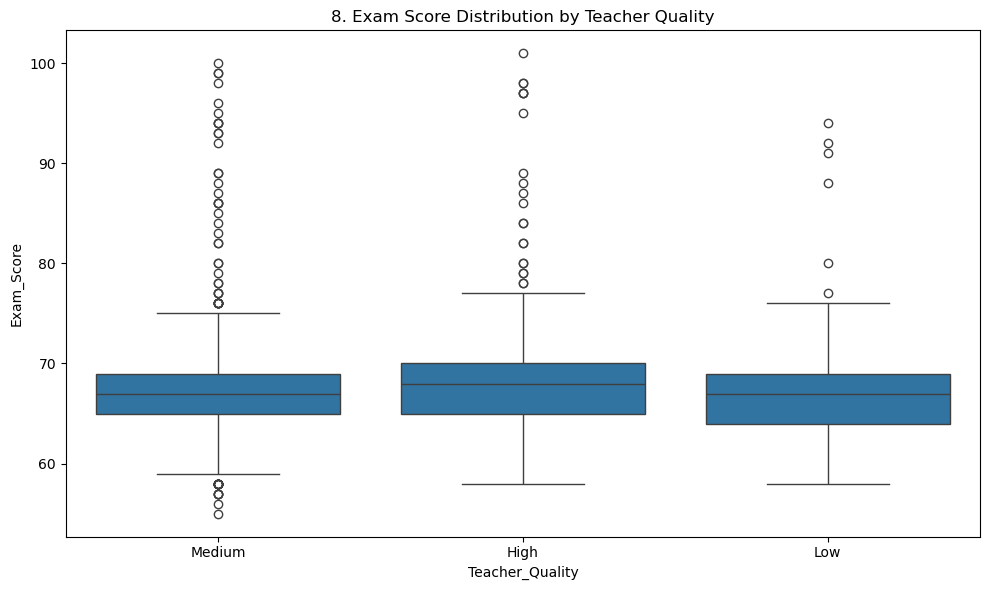

In [36]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Teacher_Quality', y='Exam_Score')
plt.title(f'{plot_no}. Exam Score Distribution by Teacher Quality')
show_fig()
plot_no += 1

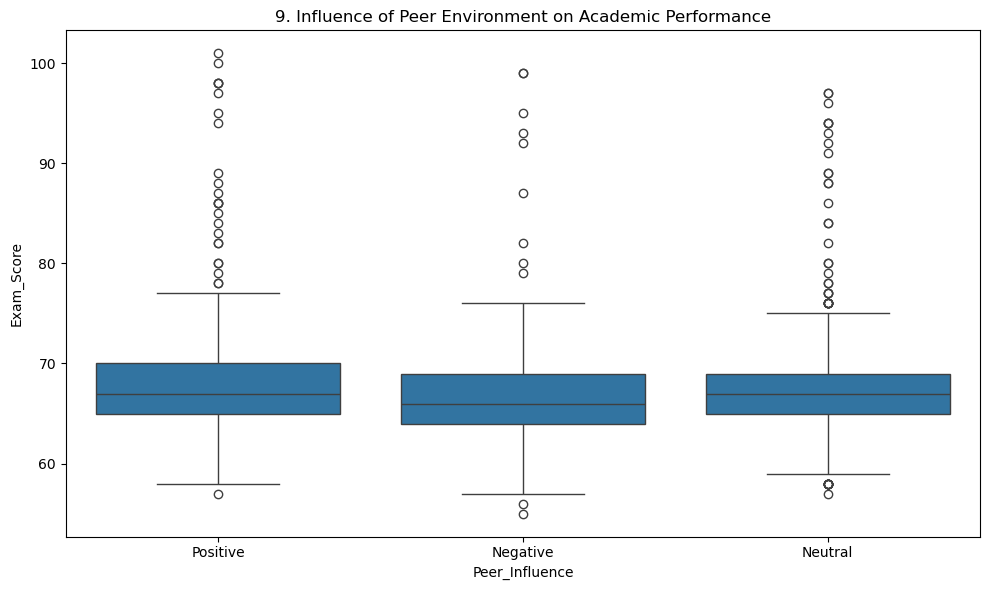

In [37]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Peer_Influence', y='Exam_Score')
plt.title(f'{plot_no}. Influence of Peer Environment on Academic Performance')
show_fig()
plot_no += 1

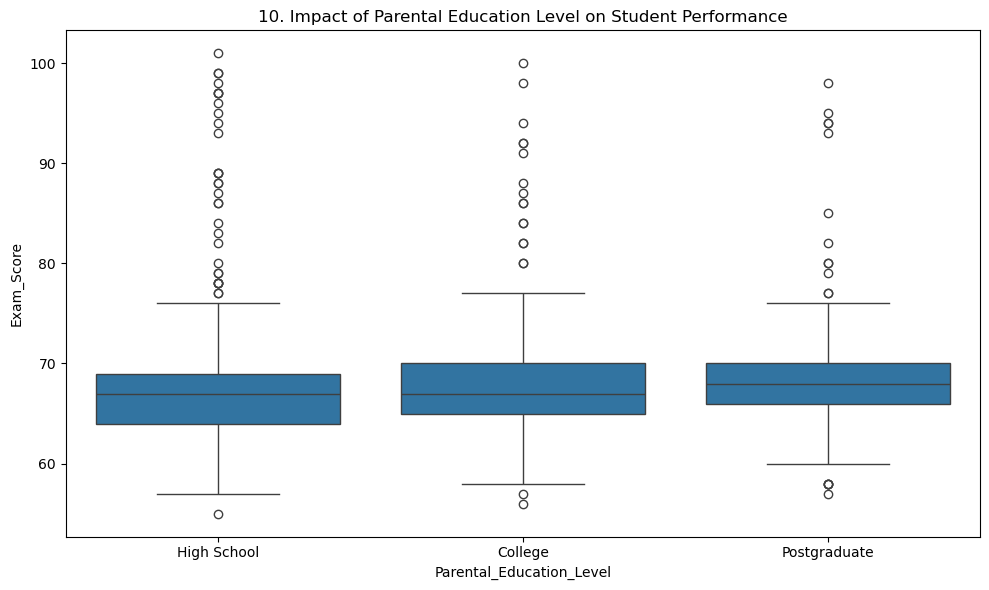

In [38]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Parental_Education_Level', y='Exam_Score')
plt.title(f'{plot_no}. Impact of Parental Education Level on Student Performance')
show_fig()
plot_no += 1

(<Figure size 640x480 with 1 Axes>, <Axes: >)

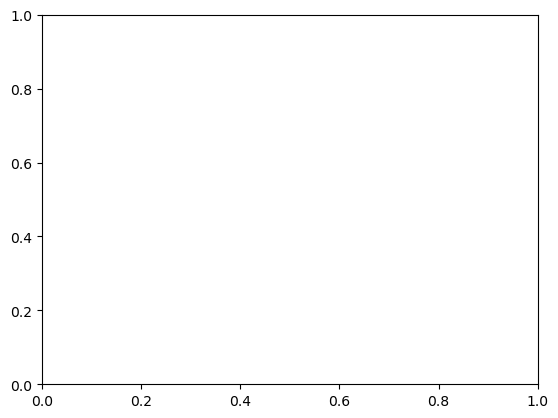

In [39]:
plt.subplots()

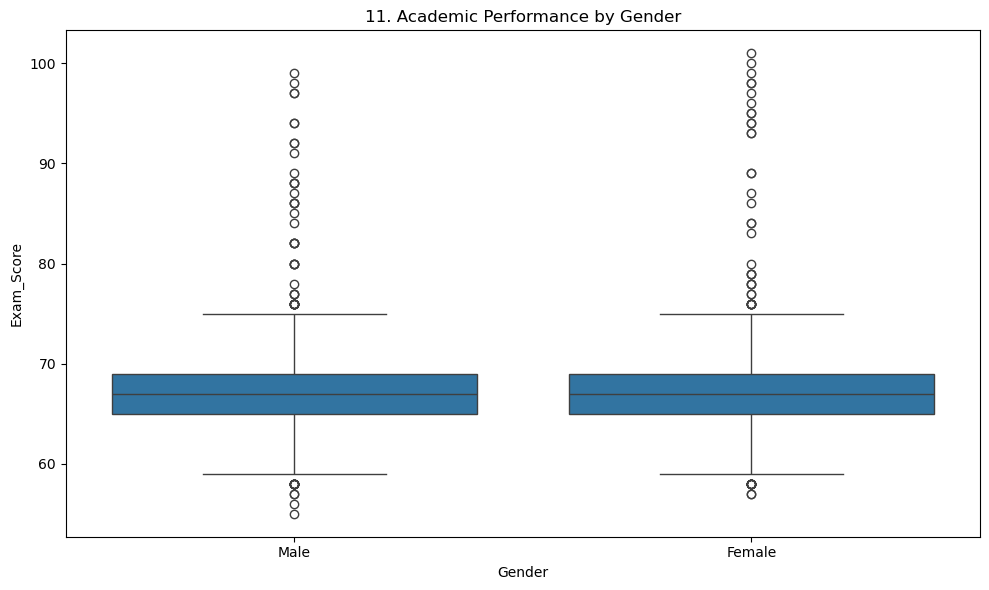

In [40]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Gender', y='Exam_Score')
plt.title(f'{plot_no}. Academic Performance by Gender')
show_fig()
plot_no += 1

Model Accuracy: 91.3 %


<Figure size 600x600 with 0 Axes>

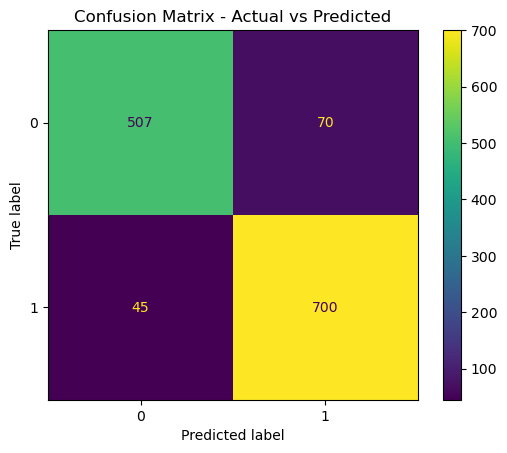

In [42]:
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

median_score = df_encoded['Exam_Score'].median()
df_encoded['Target'] = (df_encoded['Exam_Score'] >= median_score).astype(int)

X = df_encoded.drop(['Exam_Score', 'Target'], axis=1)
y = df_encoded['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC(kernel='rbf')
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

cm = confusion_matrix(y_test, y_pred)
fig = plt.figure(figsize=(6,6))
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix - Actual vs Predicted")
plt.show()